# Classifying Alzheimer's Disease Using Deep Learning on fMRI
## BiLSTM on Raw BOLD Time Series

**Student:** Kirankumar Chikkamankanala Somashekar
**Date:** August 26, 2026 | **Version:** v1
**Dataset:** 218 subjects (109 AD, 109 CN), TR=3.0s, 191 time points, 132 ROIs

**Current standings:**
- SVM Linear: 71.3% / 0.777 AUC (best overall)
- GCN+Skip: 66.4% / 0.740 AUC (best graph model)

**Why BiLSTM:** All previous models use static FC (a single correlation matrix). The BiLSTM
processes the raw BOLD time series directly, capturing temporal dynamics that FC discards.
This tests Gap 1: does temporal information carry diagnostic value?

---
**Contents:**
1. Setup
2. Data Loading
3. Model Architectures
4. Training Engine
5. Experiments
6. Results and Comparison
7. Save All Results

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import pickle, os, copy, time, warnings
from datetime import datetime
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix, roc_curve, auc)

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':300,'font.size':11,
                     'axes.titlesize':13,'axes.titleweight':'bold','savefig.bbox':'tight'})

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

Mounted at /content/drive
Device: cuda | PyTorch: 2.11.0+cu128


In [ ]:
BASE = '/content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/data'
RESULTS_BASE = '/content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results'
NB_RESULTS = os.path.join(RESULTS_BASE, 'nb03_bilstm')
NB_FIGURES = os.path.join(NB_RESULTS, 'figures')
os.makedirs(NB_RESULTS, exist_ok=True)
os.makedirs(NB_FIGURES, exist_ok=True)
print(f'Data: {BASE}\nResults: {NB_RESULTS}')

Data: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/data
Results: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb03_bilstm


## 2. Data Loading

In [ ]:
# BiLSTM data: 218 subjects, TR=3.0s, truncated to T=191
X_bold = np.load(f'{BASE}/X_bold_tr3.npy')            # (218, 191, 132)
y_bold = np.load(f'{BASE}/y_labels_tr3.npy')           # (218,)
subject_ids = np.load(f'{BASE}/subject_ids_tr3.npy', allow_pickle=True)

with open(f'{BASE}/cv_folds_bilstm.pkl', 'rb') as f:
    cv_folds = pickle.load(f)

# Load previous results for comparison
with open(os.path.join(RESULTS_BASE, 'nb01_baseline', 'baseline_results.pkl'), 'rb') as f:
    baseline_results = pickle.load(f)
with open(os.path.join(RESULTS_BASE, 'nb02_gcn', 'gcn_results.pkl'), 'rb') as f:
    gcn_results = pickle.load(f)

N_SUBJECTS, T, N_ROIS = X_bold.shape

print(f'BOLD data: {X_bold.shape} (subjects, time_points, ROIs)')
print(f'Labels: CN={int((y_bold==0).sum())}, AD={int((y_bold==1).sum())}')
print(f'Time points: {T}, ROIs: {N_ROIS}')
print(f'CV folds: {len(cv_folds)}')
print(f'NaN: {np.isnan(X_bold).sum()}, Inf: {np.isinf(X_bold).sum()}')

# Verify z-scoring
sample_means = X_bold[:5].mean(axis=1).mean(axis=0)  # per-ROI mean across time
sample_stds = X_bold[:5].std(axis=1).mean(axis=0)
print(f'Z-score check: mean~{sample_means.mean():.4f}, std~{sample_stds.mean():.4f}')

BOLD data: (218, 191, 132) (subjects, time_points, ROIs)
Labels: CN=109, AD=109
Time points: 191, ROIs: 132
CV folds: 5
NaN: 0, Inf: 0
Z-score check: mean~-0.0005, std~1.0002


## 3. Model Architectures

### PyTorch Dataset for BOLD time series
Wraps the numpy arrays into a PyTorch Dataset for use with DataLoader.

In [ ]:
class BOLDDataset(Dataset):
    """PyTorch Dataset for BOLD time series."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, T, ROIs)
        self.y = torch.tensor(y, dtype=torch.long)      # (N,)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

print(f'Dataset class defined. Sample: X={X_bold[0].shape}, y={y_bold[0]}')

Dataset class defined. Sample: X=(191, 132), y=1


### BiLSTM Architectures

Three temporal pooling strategies:
- **Last hidden state:** Uses the final LSTM output (captures end-of-sequence context)
- **Mean pooling:** Averages all time step outputs (captures overall temporal pattern)
- **Attention pooling:** Learns which time points are most important for classification

In [ ]:
class TemporalAttention(nn.Module):
    """
    Attention mechanism over time steps.
    Learns which time points are most important for classification.
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, lstm_output):
        # lstm_output: (batch, T, hidden)
        scores = self.attn(lstm_output)          # (batch, T, 1)
        weights = F.softmax(scores, dim=1)       # (batch, T, 1)
        context = (lstm_output * weights).sum(1)  # (batch, hidden)
        return context, weights.squeeze(-1)       # return weights for analysis


class BrainBiLSTM(nn.Module):
    """
    BiLSTM for BOLD time series classification.

    Input: (batch, T=191, ROIs=132)
    At each time step, the LSTM sees all 132 ROI values simultaneously.
    The bidirectional LSTM reads the sequence forward AND backward,
    capturing temporal dependencies in both directions.
    """
    def __init__(self, input_size=132, hidden_size=64, num_layers=1,
                 dropout=0.5, pooling='mean', n_classes=2):
        super().__init__()
        self.pooling_type = pooling
        self.hidden_size = hidden_size

        # Input projection: reduce ROI dimension if needed
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.ln = nn.LayerNorm(hidden_size * 2)  # bidirectional = 2x

        # Temporal pooling
        if pooling == 'attention':
            self.attention = TemporalAttention(hidden_size * 2)

        # Classifier
        lstm_out_dim = hidden_size * 2  # bidirectional
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (batch, T=191, ROIs=132)

        # Project input
        x = self.input_proj(x)  # (batch, T, hidden)

        # BiLSTM
        lstm_out, (h_n, c_n) = self.lstm(x)  # (batch, T, hidden*2)
        lstm_out = self.ln(lstm_out)

        # Temporal pooling
        if self.pooling_type == 'last':
            # Concatenate last forward and last backward hidden states
            h_fwd = h_n[-2]   # last layer forward
            h_bwd = h_n[-1]   # last layer backward
            pooled = torch.cat([h_fwd, h_bwd], dim=1)
        elif self.pooling_type == 'mean':
            pooled = lstm_out.mean(dim=1)  # average over all time steps
        elif self.pooling_type == 'attention':
            pooled, self.attn_weights = self.attention(lstm_out)
        else:
            raise ValueError(f'Unknown pooling: {self.pooling_type}')

        return self.classifier(pooled)


# Parameter counts
for pool in ['last', 'mean', 'attention']:
    m = BrainBiLSTM(input_size=132, hidden_size=64, num_layers=1, pooling=pool)
    p = sum(p.numel() for p in m.parameters())
    print(f'BiLSTM h64 L1 {pool}: {p:,} params')

m2 = BrainBiLSTM(input_size=132, hidden_size=128, num_layers=2, pooling='attention')
print(f'BiLSTM h128 L2 attention: {sum(p.numel() for p in m2.parameters()):,} params')

BiLSTM h64 L1 last: 83,970 params
BiLSTM h64 L1 mean: 83,970 params
BiLSTM h64 L1 attention: 92,291 params
BiLSTM h128 L2 attention: 743,683 params


## 4. Training Engine

In [ ]:
def train_epoch_lstm(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = model(X_batch)
        if torch.isnan(out).any(): continue
        loss = criterion(out, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (out.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / max(total,1), correct / max(total,1)


@torch.no_grad()
def eval_lstm(model, loader, device):
    model.eval()
    preds, probs, labels, total_loss = [], [], [], 0
    crit = nn.CrossEntropyLoss()
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        out = model(X_batch)
        if torch.isnan(out).any(): out = torch.nan_to_num(out)
        total_loss += crit(out, y_batch).item() * len(y_batch)
        p = F.softmax(out, dim=1)
        preds.extend(out.argmax(1).cpu().numpy())
        probs.extend(p[:,1].cpu().numpy())
        labels.extend(y_batch.cpu().numpy())
    return np.array(preds), np.array(probs), np.array(labels), total_loss/len(loader.dataset)

print('LSTM training functions defined.')

LSTM training functions defined.


In [ ]:
def run_bilstm_cv(X, y, cv_folds, config, device):
    """Run BiLSTM with 5-fold CV. Returns standardised results dict."""
    t_start = time.time()
    metrics = {k:[] for k in ['accuracy','f1','precision','recall','auc_roc']}
    all_true, all_pred, all_prob = [], [], []
    histories = []

    print(f'\n{"="*60}')
    print(f'{config["name"]}')
    print(f'Hidden={config["hidden"]}, Layers={config["layers"]}, '
          f'Pool={config["pooling"]}, Drop={config["dropout"]}, LR={config["lr"]}')
    print(f'{"="*60}')

    for fi, (tr_idx, te_idx) in enumerate(cv_folds):
        tr_ds = BOLDDataset(X[tr_idx], y[tr_idx])
        te_ds = BOLDDataset(X[te_idx], y[te_idx])
        tr_ld = DataLoader(tr_ds, batch_size=config['bs'], shuffle=True)
        te_ld = DataLoader(te_ds, batch_size=config['bs'], shuffle=False)

        model = BrainBiLSTM(
            input_size=N_ROIS, hidden_size=config['hidden'],
            num_layers=config['layers'], dropout=config['dropout'],
            pooling=config['pooling']
        ).to(device)

        opt = Adam(model.parameters(), lr=config['lr'], weight_decay=config['wd'])
        crit = nn.CrossEntropyLoss()
        sched = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=15)

        best_loss, best_state, wait = float('inf'), copy.deepcopy(model.state_dict()), 0
        hist = {'tl':[],'vl':[],'ta':[],'va':[]}

        for ep in range(config['epochs']):
            tl, ta = train_epoch_lstm(model, tr_ld, opt, crit, device)
            pr, pb, lb, vl = eval_lstm(model, te_ld, device)
            va = accuracy_score(lb, pr)
            hist['tl'].append(tl); hist['vl'].append(vl)
            hist['ta'].append(ta); hist['va'].append(va)
            sched.step(vl)
            if vl < best_loss:
                best_loss = vl; best_state = copy.deepcopy(model.state_dict()); wait = 0
            else: wait += 1
            if wait >= config['patience']: break

        model.load_state_dict(best_state)
        pr, pb, lb, _ = eval_lstm(model, te_ld, device)
        acc = accuracy_score(lb,pr); f1 = f1_score(lb,pr,average='macro',zero_division=0)
        prec = precision_score(lb,pr,average='macro',zero_division=0)
        rec = recall_score(lb,pr,average='macro',zero_division=0)
        try: auc_v = roc_auc_score(lb,pb)
        except: auc_v = 0.5

        for k,v in zip(metrics.keys(),[acc,f1,prec,rec,auc_v]): metrics[k].append(v)
        all_true.extend(lb.tolist()); all_pred.extend(pr.tolist()); all_prob.extend(pb.tolist())
        histories.append(hist)
        print(f'  Fold {fi+1}: Acc={acc:.4f} F1={f1:.4f} AUC={auc_v:.4f} Ep={len(hist["tl"])}')

    elapsed = time.time() - t_start
    res = {'model_name':config['name'], 'model_type':'bilstm', 'n_subjects':N_SUBJECTS,
           'n_features':f'{T}x{N_ROIS} temporal', 'config':config,
           'training_time_seconds':elapsed, 'fold_histories':histories,
           'y_true_all':all_true, 'y_pred_all':all_pred, 'y_prob_all':all_prob,
           'date':datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
    for m in metrics:
        res[f'{m}_mean']=np.mean(metrics[m]); res[f'{m}_std']=np.std(metrics[m])
        res[f'{m}_per_fold']=metrics[m]

    print(f'  >> Acc={res["accuracy_mean"]:.4f}+/-{res["accuracy_std"]:.4f} '
          f'AUC={res["auc_roc_mean"]:.4f}+/-{res["auc_roc_std"]:.4f} ({elapsed:.0f}s)')
    return res

print('CV runner defined.')

CV runner defined.


## 5. Experiments

### 5.1 Compare Pooling Strategies (h64, L1)

In [ ]:
tc = {'bs':32, 'epochs':300, 'patience':30, 'lr':1e-3, 'wd':5e-4}
all_results = []

for pool in ['last', 'mean', 'attention']:
    cfg = {**tc, 'name':f'BiLSTM h64 L1 {pool}', 'hidden':64, 'layers':1,
           'dropout':0.5, 'pooling':pool}
    r = run_bilstm_cv(X_bold, y_bold, cv_folds, cfg, DEVICE)
    all_results.append(r)


BiLSTM h64 L1 last
Hidden=64, Layers=1, Pool=last, Drop=0.5, LR=0.001
  Fold 1: Acc=0.4375 F1=0.4170 AUC=0.4157 Ep=31
  Fold 2: Acc=0.5116 F1=0.5106 AUC=0.5152 Ep=32
  Fold 3: Acc=0.4500 F1=0.4133 AUC=0.4286 Ep=31
  Fold 4: Acc=0.4545 F1=0.4442 AUC=0.5021 Ep=31
  Fold 5: Acc=0.5814 F1=0.5700 AUC=0.6061 Ep=32
  >> Acc=0.4870+/-0.0536 AUC=0.4935+/-0.0685 (14s)

BiLSTM h64 L1 mean
Hidden=64, Layers=1, Pool=mean, Drop=0.5, LR=0.001
  Fold 1: Acc=0.8125 F1=0.8118 AUC=0.8852 Ep=68
  Fold 2: Acc=0.7442 F1=0.7420 AUC=0.8680 Ep=42
  Fold 3: Acc=0.6000 F1=0.5960 AUC=0.7444 Ep=39
  Fold 4: Acc=0.7273 F1=0.7250 AUC=0.7603 Ep=34
  Fold 5: Acc=0.4651 F1=0.3175 AUC=0.6299 Ep=31
  >> Acc=0.6698+/-0.1233 AUC=0.7775+/-0.0927 (10s)

BiLSTM h64 L1 attention
Hidden=64, Layers=1, Pool=attention, Drop=0.5, LR=0.001
  Fold 1: Acc=0.6458 F1=0.6178 AUC=0.7304 Ep=35
  Fold 2: Acc=0.6279 F1=0.6109 AUC=0.6818 Ep=35
  Fold 3: Acc=0.8250 F1=0.8240 AUC=0.8697 Ep=38
  Fold 4: Acc=0.5000 F1=0.4990 AUC=0.5847 Ep=32
  F

### 5.2 Best Pooling with Different Hidden Sizes

In [ ]:
# Find best pooling from 5.1
best_pool = max(all_results, key=lambda r: r['accuracy_mean'])['config']['pooling']
print(f'Best pooling: {best_pool}')

for hidden in [128, 256]:
    cfg = {**tc, 'name':f'BiLSTM h{hidden} L1 {best_pool}', 'hidden':hidden,
           'layers':1, 'dropout':0.5, 'pooling':best_pool}
    r = run_bilstm_cv(X_bold, y_bold, cv_folds, cfg, DEVICE)
    all_results.append(r)

Best pooling: mean

BiLSTM h128 L1 mean
Hidden=128, Layers=1, Pool=mean, Drop=0.5, LR=0.001
  Fold 1: Acc=0.8542 F1=0.8541 AUC=0.8974 Ep=67
  Fold 2: Acc=0.7674 F1=0.7673 AUC=0.8182 Ep=37
  Fold 3: Acc=0.6500 F1=0.6267 AUC=0.8371 Ep=37
  Fold 4: Acc=0.6591 F1=0.6589 AUC=0.6818 Ep=33
  Fold 5: Acc=0.5349 F1=0.4881 AUC=0.4740 Ep=31
  >> Acc=0.6931+/-0.1091 AUC=0.7417+/-0.1513 (10s)

BiLSTM h256 L1 mean
Hidden=256, Layers=1, Pool=mean, Drop=0.5, LR=0.001
  Fold 1: Acc=0.8333 F1=0.8307 AUC=0.9148 Ep=83
  Fold 2: Acc=0.7442 F1=0.7436 AUC=0.8268 Ep=34
  Fold 3: Acc=0.5250 F1=0.4203 AUC=0.7268 Ep=33
  Fold 4: Acc=0.5000 F1=0.3333 AUC=0.7128 Ep=31
  Fold 5: Acc=0.6047 F1=0.5968 AUC=0.7013 Ep=33
  >> Acc=0.6414+/-0.1283 AUC=0.7765+/-0.0823 (26s)


### 5.3 Best Pooling with 2 Layers

In [ ]:
for hidden in [64, 128]:
    cfg = {**tc, 'name':f'BiLSTM h{hidden} L2 {best_pool}', 'hidden':hidden,
           'layers':2, 'dropout':0.5, 'pooling':best_pool}
    r = run_bilstm_cv(X_bold, y_bold, cv_folds, cfg, DEVICE)
    all_results.append(r)


BiLSTM h64 L2 mean
Hidden=64, Layers=2, Pool=mean, Drop=0.5, LR=0.001
  Fold 1: Acc=0.6250 F1=0.6190 AUC=0.6661 Ep=34
  Fold 2: Acc=0.8140 F1=0.8139 AUC=0.9351 Ep=45
  Fold 3: Acc=0.7750 F1=0.7749 AUC=0.8321 Ep=41
  Fold 4: Acc=0.5000 F1=0.3333 AUC=0.5103 Ep=31
  Fold 5: Acc=0.6047 F1=0.5905 AUC=0.7078 Ep=35
  >> Acc=0.6637+/-0.1155 AUC=0.7303+/-0.1451 (10s)

BiLSTM h128 L2 mean
Hidden=128, Layers=2, Pool=mean, Drop=0.5, LR=0.001
  Fold 1: Acc=0.8125 F1=0.8118 AUC=0.9026 Ep=64
  Fold 2: Acc=0.6512 F1=0.6312 AUC=0.7554 Ep=34
  Fold 3: Acc=0.4750 F1=0.3220 AUC=0.6767 Ep=31
  Fold 4: Acc=0.6364 F1=0.5810 AUC=0.7603 Ep=34
  Fold 5: Acc=0.5814 F1=0.5393 AUC=0.6190 Ep=31
  >> Acc=0.6313+/-0.1097 AUC=0.7428+/-0.0956 (13s)


### 5.4 Fine-Tuning Best Configuration

In [ ]:
best_tmp = max(all_results, key=lambda r: r['accuracy_mean'])
print(f'Best so far: {best_tmp["model_name"]} Acc={best_tmp["accuracy_mean"]:.4f}')

best_h = best_tmp['config']['hidden']
best_l = best_tmp['config']['layers']

# Try lower dropout and different LR
for name, drop, lr, wd in [
    ('drop0.3', 0.3, 1e-3, 5e-4),
    ('lr5e-4', 0.5, 5e-4, 5e-4),
    ('lr1e-4', 0.5, 1e-4, 1e-4),
    ('drop0.3 lr5e-4', 0.3, 5e-4, 1e-4),
]:
    cfg = {**tc, 'name':f'BiLSTM h{best_h} L{best_l} {best_pool} {name}',
           'hidden':best_h, 'layers':best_l, 'dropout':drop,
           'pooling':best_pool, 'lr':lr, 'wd':wd}
    r = run_bilstm_cv(X_bold, y_bold, cv_folds, cfg, DEVICE)
    all_results.append(r)

Best so far: BiLSTM h128 L1 mean Acc=0.6931

BiLSTM h128 L1 mean drop0.3
Hidden=128, Layers=1, Pool=mean, Drop=0.3, LR=0.001
  Fold 1: Acc=0.7292 F1=0.7262 AUC=0.8087 Ep=34
  Fold 2: Acc=0.6744 F1=0.6700 AUC=0.7857 Ep=36
  Fold 3: Acc=0.7500 F1=0.7396 AUC=0.8321 Ep=31
  Fold 4: Acc=0.5000 F1=0.3333 AUC=0.4897 Ep=31
  Fold 5: Acc=0.5814 F1=0.5038 AUC=0.6688 Ep=31
  >> Acc=0.6470+/-0.0938 AUC=0.7170+/-0.1268 (8s)

BiLSTM h128 L1 mean lr5e-4
Hidden=128, Layers=1, Pool=mean, Drop=0.5, LR=0.0005
  Fold 1: Acc=0.7708 F1=0.7659 AUC=0.8591 Ep=37
  Fold 2: Acc=0.5814 F1=0.5757 AUC=0.6147 Ep=34
  Fold 3: Acc=0.6000 F1=0.5960 AUC=0.6541 Ep=32
  Fold 4: Acc=0.5000 F1=0.3333 AUC=0.7252 Ep=31
  Fold 5: Acc=0.6279 F1=0.6228 AUC=0.6558 Ep=32
  >> Acc=0.6160+/-0.0883 AUC=0.7018+/-0.0863 (8s)

BiLSTM h128 L1 mean lr1e-4
Hidden=128, Layers=1, Pool=mean, Drop=0.5, LR=0.0001
  Fold 1: Acc=0.8125 F1=0.8104 AUC=0.8487 Ep=61
  Fold 2: Acc=0.5116 F1=0.3385 AUC=0.5779 Ep=33
  Fold 3: Acc=0.5500 F1=0.5455 AUC=0.

## 6. Results and Comparison

### 6.1 All BiLSTM Experiments (Ranked)

In [ ]:
all_results.sort(key=lambda r: r['accuracy_mean'], reverse=True)

res_df = pd.DataFrame({
    'Rank': range(1, len(all_results)+1),
    'Model': [r['model_name'] for r in all_results],
    'Accuracy': [f"{r['accuracy_mean']:.4f}+/-{r['accuracy_std']:.4f}" for r in all_results],
    'F1': [f"{r['f1_mean']:.4f}+/-{r['f1_std']:.4f}" for r in all_results],
    'AUC-ROC': [f"{r['auc_roc_mean']:.4f}+/-{r['auc_roc_std']:.4f}" for r in all_results],
    'Time': [f"{r['training_time_seconds']:.0f}s" for r in all_results],
})
print(f'All {len(all_results)} BiLSTM Experiments')
display(res_df.style.set_properties(**{'text-align':'center'}).hide(axis='index'))
res_df.to_csv(os.path.join(NB_RESULTS, 'bilstm_all_experiments.csv'), index=False)

All 11 BiLSTM Experiments


Rank,Model,Accuracy,F1,AUC-ROC,Time
1,BiLSTM h128 L1 mean,0.6931+/-0.1091,0.6790+/-0.1249,0.7417+/-0.1513,10s
2,BiLSTM h64 L1 mean,0.6698+/-0.1233,0.6384+/-0.1750,0.7775+/-0.0927,10s
3,BiLSTM h64 L2 mean,0.6637+/-0.1155,0.6263+/-0.1699,0.7303+/-0.1451,10s
4,BiLSTM h128 L1 mean drop0.3,0.6470+/-0.0938,0.5946+/-0.1552,0.7170+/-0.1268,8s
5,BiLSTM h256 L1 mean,0.6414+/-0.1283,0.5849+/-0.1877,0.7765+/-0.0823,26s
6,BiLSTM h128 L1 mean lr1e-4,0.6329+/-0.1297,0.5738+/-0.1860,0.6253+/-0.1957,10s
7,BiLSTM h128 L2 mean,0.6313+/-0.1097,0.5771+/-0.1578,0.7428+/-0.0956,13s
8,BiLSTM h64 L1 attention,0.6267+/-0.1133,0.6160+/-0.1137,0.7023+/-0.0963,9s
9,BiLSTM h128 L1 mean lr5e-4,0.6160+/-0.0883,0.5787+/-0.1396,0.7018+/-0.0863,8s
10,BiLSTM h128 L1 mean drop0.3 lr5e-4,0.5444+/-0.0563,0.4631+/-0.1208,0.6484+/-0.0978,8s


### 6.2 Comparison with All Previous Models

In [ ]:
best_bilstm = all_results[0]
bl = baseline_results
best_gcn = gcn_results['best']

comp = pd.DataFrame([
    ['SVM (Linear) [262 subj]', bl['svm_linear']['accuracy_mean'],
     bl['svm_linear']['f1_mean'], bl['svm_linear']['auc_roc_mean'], 'Static FC'],
    ['SVM (RBF) [262 subj]', bl['svm_rbf']['accuracy_mean'],
     bl['svm_rbf']['f1_mean'], bl['svm_rbf']['auc_roc_mean'], 'Static FC'],
    ['Random Forest [262 subj]', bl['random_forest']['accuracy_mean'],
     bl['random_forest']['f1_mean'], bl['random_forest']['auc_roc_mean'], 'Static FC'],
    [f'Best GCN+Skip [262 subj]', best_gcn['accuracy_mean'],
     best_gcn['f1_mean'], best_gcn['auc_roc_mean'], 'Static FC (graph)'],
    [f'Best BiLSTM [218 subj]', best_bilstm['accuracy_mean'],
     best_bilstm['f1_mean'], best_bilstm['auc_roc_mean'], 'Raw BOLD temporal'],
], columns=['Model','Accuracy','F1','AUC-ROC','Input Type'])

print('All Models Comparison')
display(comp.style.format({'Accuracy':'{:.4f}','F1':'{:.4f}','AUC-ROC':'{:.4f}'}).\
        set_properties(**{'text-align':'center'}).hide(axis='index'))

print(f'\nBiLSTM vs SVM Linear: {best_bilstm["accuracy_mean"]-bl["svm_linear"]["accuracy_mean"]:+.4f}')
print(f'BiLSTM vs GCN+Skip:   {best_bilstm["accuracy_mean"]-best_gcn["accuracy_mean"]:+.4f}')

All Models Comparison


Model,Accuracy,F1,AUC-ROC,Input Type
SVM (Linear) [262 subj],0.7134,0.7126,0.7771,Static FC
SVM (RBF) [262 subj],0.6715,0.6697,0.7405,Static FC
Random Forest [262 subj],0.6485,0.6445,0.7211,Static FC
Best GCN+Skip [262 subj],0.6642,0.6532,0.7401,Static FC (graph)
Best BiLSTM [218 subj],0.6931,0.6790,0.7417,Raw BOLD temporal



BiLSTM vs SVM Linear: -0.0202
BiLSTM vs GCN+Skip:   +0.0290


### 6.3 Confusion Matrix and ROC Curves

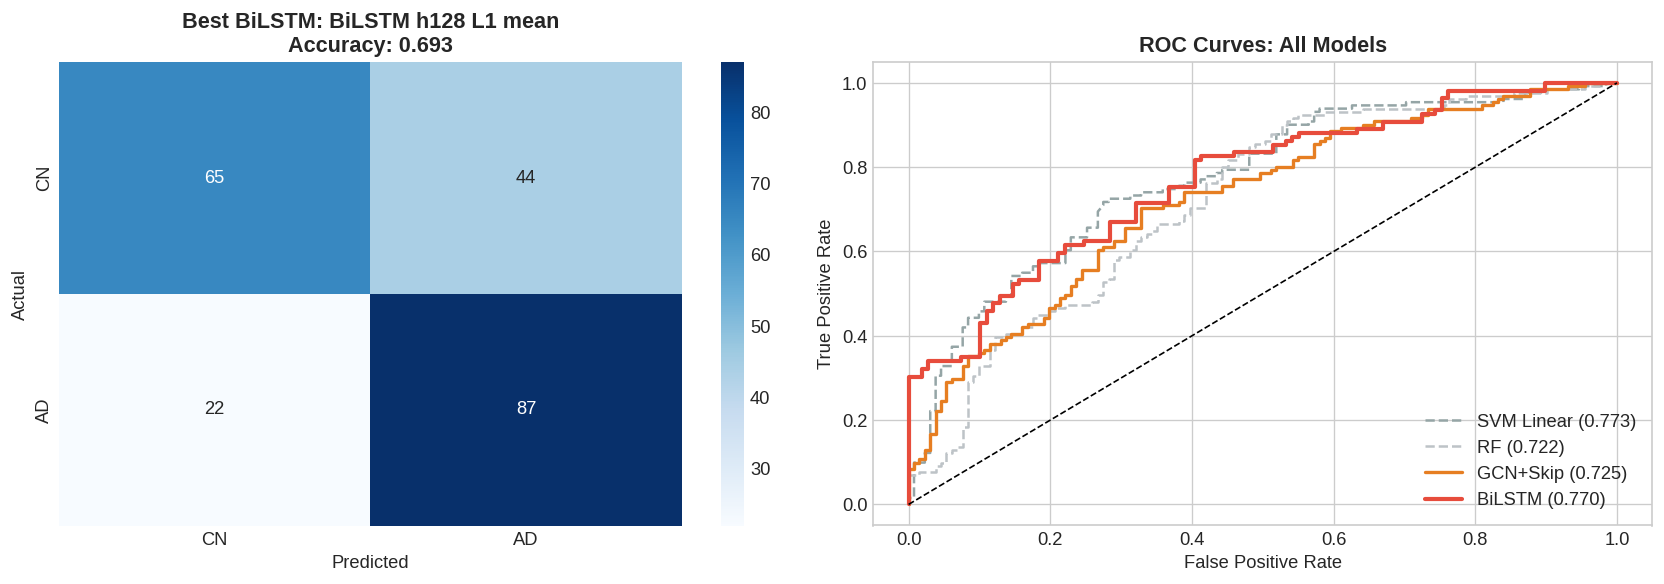

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(best_bilstm['y_true_all'], best_bilstm['y_pred_all'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['CN','AD'], yticklabels=['CN','AD'])
axes[0].set_title(f'Best BiLSTM: {best_bilstm["model_name"]}\nAccuracy: {best_bilstm["accuracy_mean"]:.3f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curves - all models
for nm, key, c, ls in [('SVM Linear','svm_linear','#95a5a6','--'),
                        ('RF','random_forest','#bdc3c7','--')]:
    r = bl[key]; fpr,tpr,_ = roc_curve(r['y_true_all'], r['y_prob_all'])
    axes[1].plot(fpr,tpr,color=c,lw=1.5,ls=ls,label=f'{nm} ({auc(fpr,tpr):.3f})')

fpr,tpr,_ = roc_curve(best_gcn['y_true_all'], best_gcn['y_prob_all'])
axes[1].plot(fpr,tpr,color='#e67e22',lw=2,ls='-',label=f'GCN+Skip ({auc(fpr,tpr):.3f})')

fpr,tpr,_ = roc_curve(best_bilstm['y_true_all'], best_bilstm['y_prob_all'])
axes[1].plot(fpr,tpr,color='#e74c3c',lw=2.5,label=f'BiLSTM ({auc(fpr,tpr):.3f})')

axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves: All Models'); axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'bilstm_cm_roc.png'))
plt.show()

### 6.4 Training Curves (Best BiLSTM)

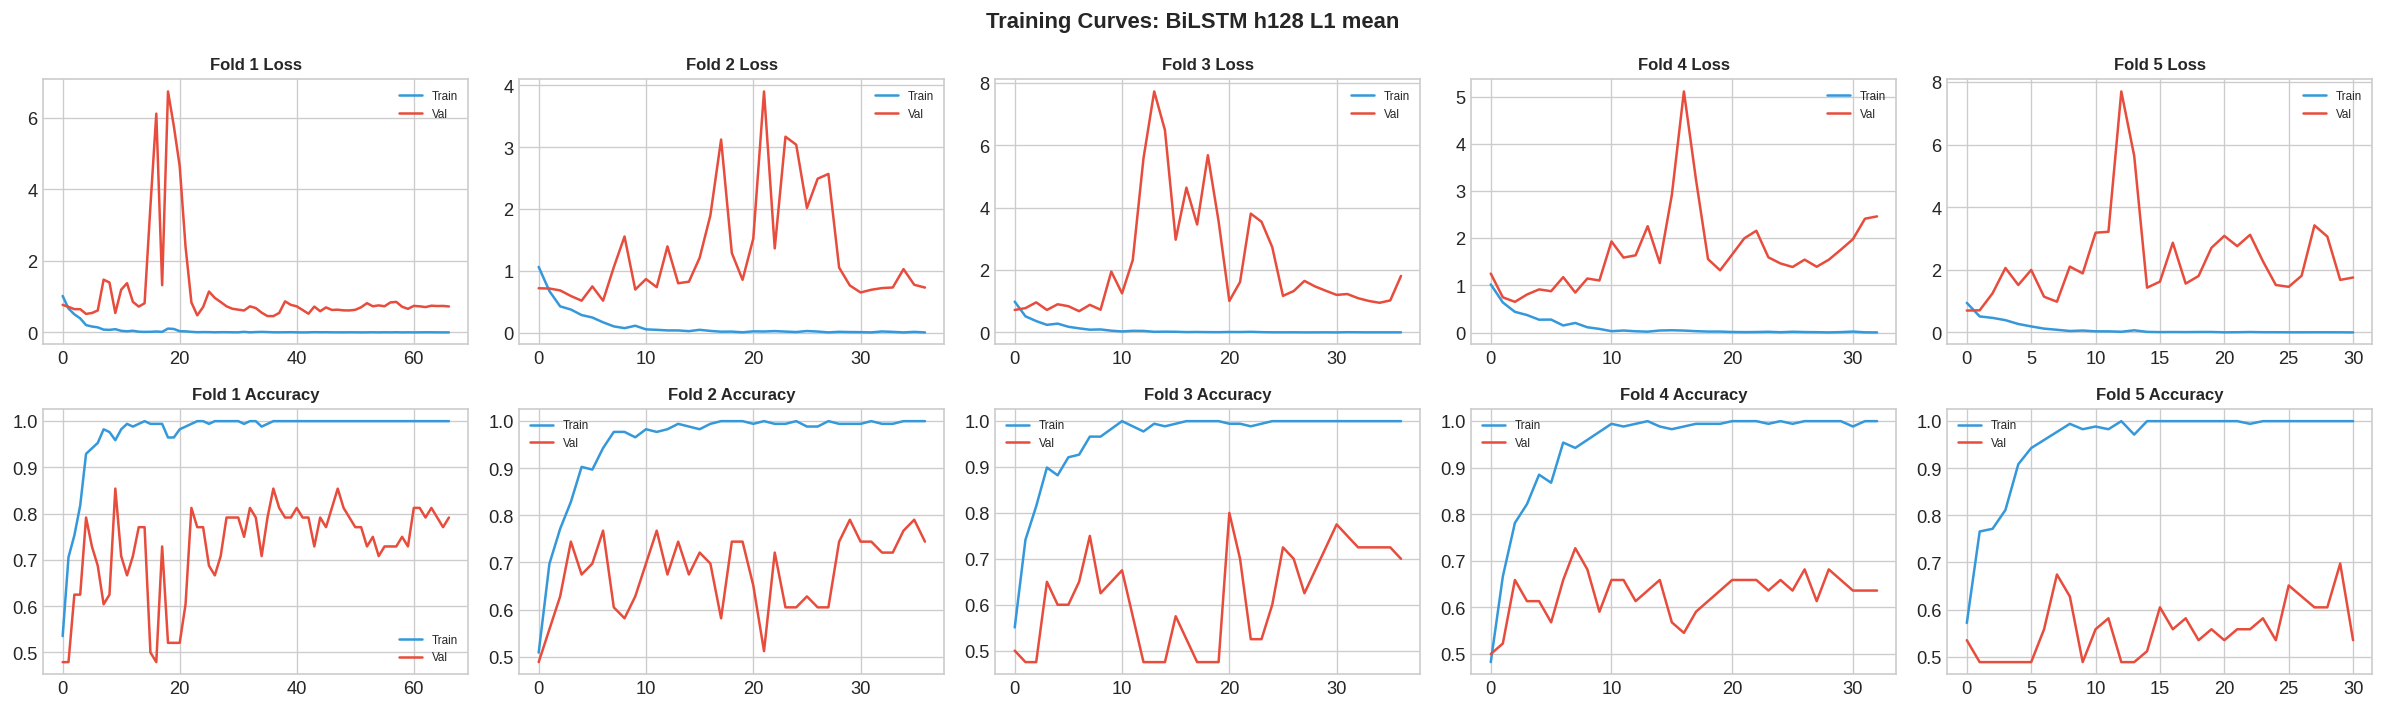

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, h in enumerate(best_bilstm['fold_histories']):
    axes[0][i].plot(h['tl'],color='#3498db',label='Train')
    axes[0][i].plot(h['vl'],color='#e74c3c',label='Val')
    axes[0][i].set_title(f'Fold {i+1} Loss',fontsize=10); axes[0][i].legend(fontsize=7)
    axes[1][i].plot(h['ta'],color='#3498db',label='Train')
    axes[1][i].plot(h['va'],color='#e74c3c',label='Val')
    axes[1][i].set_title(f'Fold {i+1} Accuracy',fontsize=10); axes[1][i].legend(fontsize=7)
plt.suptitle(f'Training Curves: {best_bilstm["model_name"]}', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'bilstm_training_curves.png'))
plt.show()

### 6.5 All BiLSTM Experiments Bar Chart

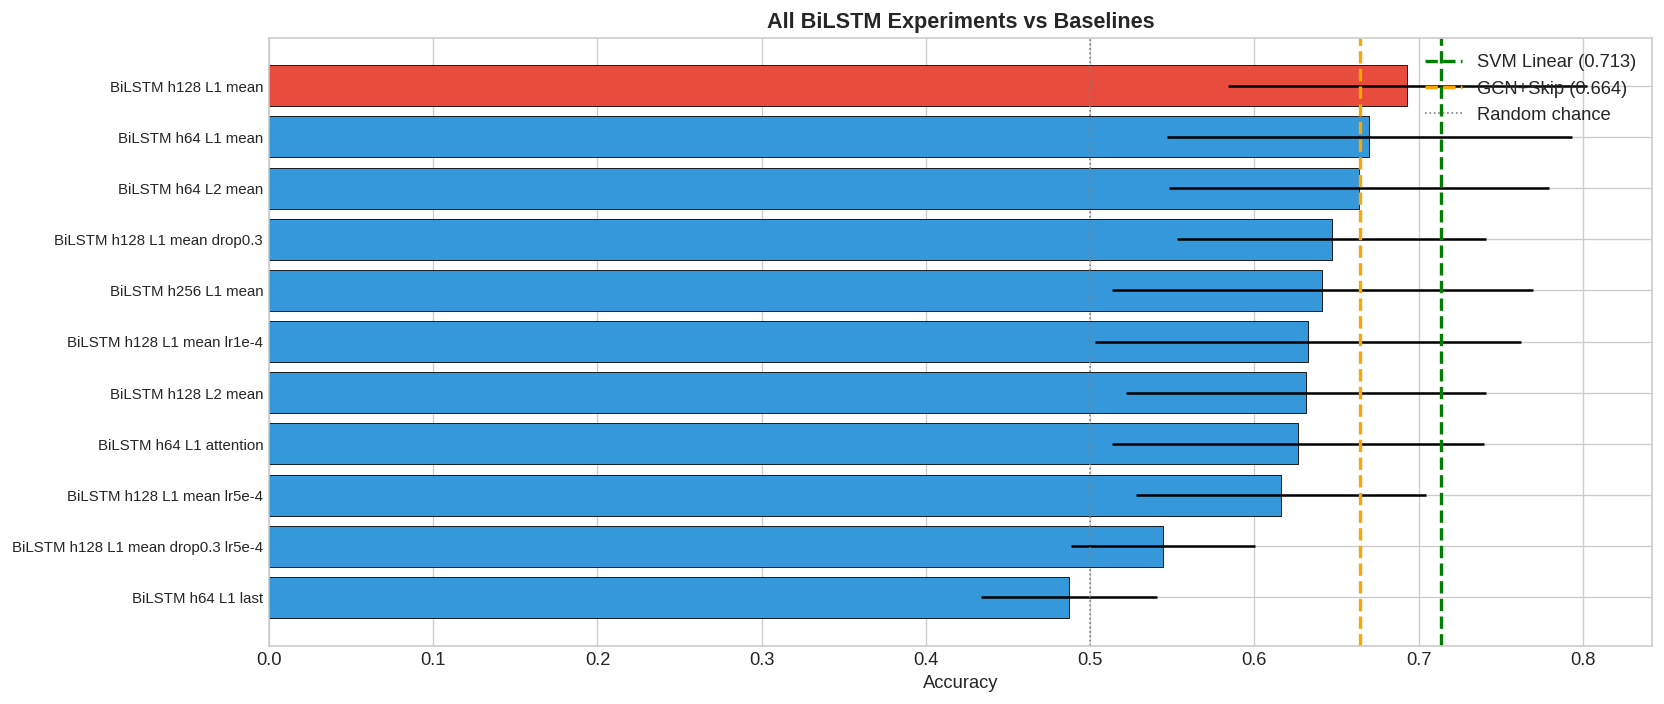

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
names = [r['model_name'] for r in all_results]
accs = [r['accuracy_mean'] for r in all_results]
stds = [r['accuracy_std'] for r in all_results]
colors = ['#e74c3c' if a==max(accs) else '#3498db' for a in accs]
ax.barh(range(len(names)), accs, xerr=stds, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
ax.axvline(x=bl['svm_linear']['accuracy_mean'], color='green', ls='--', lw=2,
           label=f'SVM Linear ({bl["svm_linear"]["accuracy_mean"]:.3f})')
ax.axvline(x=best_gcn['accuracy_mean'], color='orange', ls='--', lw=2,
           label=f'GCN+Skip ({best_gcn["accuracy_mean"]:.3f})')
ax.axvline(x=0.5, color='gray', ls=':', lw=1, label='Random chance')
ax.set_xlabel('Accuracy'); ax.set_title('All BiLSTM Experiments vs Baselines')
ax.legend(); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'bilstm_all_experiments_bar.png'))
plt.show()

### 6.6 Pooling Strategy Comparison

In [ ]:
pool_results = [r for r in all_results if 'h64 L1' in r['model_name'] and
                any(p in r['model_name'] for p in ['last','mean','attention'])]
if len(pool_results) >= 3:
    pool_df = pd.DataFrame({
        'Pooling': [r['config']['pooling'] for r in pool_results],
        'Accuracy': [f"{r['accuracy_mean']:.4f}" for r in pool_results],
        'F1': [f"{r['f1_mean']:.4f}" for r in pool_results],
        'AUC-ROC': [f"{r['auc_roc_mean']:.4f}" for r in pool_results],
    })
    print('Temporal Pooling Strategy Comparison (h64, L1)')
    display(pool_df.style.set_properties(**{'text-align':'center'}).hide(axis='index'))
    print(f'\nBest pooling strategy: {best_pool}')

Temporal Pooling Strategy Comparison (h64, L1)


Pooling,Accuracy,F1,AUC-ROC
mean,0.6698,0.6384,0.7775
attention,0.6267,0.6160,0.7023
last,0.4870,0.4710,0.4935



Best pooling strategy: mean


## 7. Save All Results

In [ ]:
# Save pickle
bilstm_save = {'best':best_bilstm, 'all_results':all_results,
               'n_experiments':len(all_results),
               'date':datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
pkl_path = os.path.join(NB_RESULTS, 'bilstm_results.pkl')
with open(pkl_path,'wb') as f: pickle.dump(bilstm_save, f)
print(f'Saved: {pkl_path}')

# Append to master CSV
summary_csv = os.path.join(RESULTS_BASE, 'all_results_summary.csv')
rows = [{'model_name':r['model_name'],'model_type':'bilstm','n_subjects':r['n_subjects'],
         'accuracy_mean':f"{r['accuracy_mean']:.4f}",'accuracy_std':f"{r['accuracy_std']:.4f}",
         'f1_mean':f"{r['f1_mean']:.4f}",'f1_std':f"{r['f1_std']:.4f}",
         'auc_roc_mean':f"{r['auc_roc_mean']:.4f}",'auc_roc_std':f"{r['auc_roc_std']:.4f}",
         'time_seconds':f"{r['training_time_seconds']:.0f}",'notebook':'nb03_bilstm',
         'date':r['date']} for r in all_results]
new_df = pd.DataFrame(rows)
if os.path.exists(summary_csv):
    existing = pd.read_csv(summary_csv)
    existing = existing[existing['notebook']!='nb03_bilstm']
    combined = pd.concat([existing, new_df], ignore_index=True)
else: combined = new_df
combined.to_csv(summary_csv, index=False)
print(f'Saved: {summary_csv}')
display(combined.style.set_caption('Master Results Summary').hide(axis='index').\
        set_properties(**{'text-align':'center'}))

# Markdown report
rpt = os.path.join(NB_RESULTS, 'bilstm_report.md')
with open(rpt, 'w') as f:
    f.write('# BiLSTM Results Report\n\n')
    f.write(f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Subjects: {N_SUBJECTS} (TR=3.0s), T={T}, ROIs={N_ROIS}\n')
    f.write(f'Experiments: {len(all_results)}\n\n')
    f.write('| Rank | Model | Accuracy | F1 | AUC-ROC |\n')
    f.write('|------|-------|----------|-----|---------|\n')
    for i,r in enumerate(all_results):
        f.write(f'| {i+1} | {r["model_name"]} | {r["accuracy_mean"]:.4f}+/-{r["accuracy_std"]:.4f} | '
                f'{r["f1_mean"]:.4f}+/-{r["f1_std"]:.4f} | {r["auc_roc_mean"]:.4f}+/-{r["auc_roc_std"]:.4f} |\n')
    f.write(f'\nBest baseline (SVM Linear): {bl["svm_linear"]["accuracy_mean"]:.4f}\n')
    f.write(f'Best GCN: {best_gcn["accuracy_mean"]:.4f}\n')
    f.write(f'Best BiLSTM: {best_bilstm["accuracy_mean"]:.4f}\n')
print(f'Saved: {rpt}')

Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb03_bilstm/bilstm_results.pkl
Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/all_results_summary.csv


model_name,model_type,n_subjects,accuracy_mean,accuracy_std,f1_mean,f1_std,auc_roc_mean,auc_roc_std,time_seconds,notebook,date
SVM (Linear),classical_ml,262,0.713400,0.057300,0.712600,0.057200,0.777100,0.051300,4.600000,nb01_baseline,2026-08-26 16:28:12
SVM (RBF),classical_ml,262,0.671500,0.056000,0.669700,0.055700,0.740500,0.076200,5.800000,nb01_baseline,2026-08-26 16:28:18
Random Forest,classical_ml,262,0.648500,0.058800,0.644500,0.059000,0.721100,0.059400,6.400000,nb01_baseline,2026-08-26 16:28:25
GCN+Skip Thresh-0.2 h64 L2,gcn,262,0.664200,0.066400,0.653200,0.070200,0.740100,0.069500,28.000000,nb02_gcn,2026-08-26 16:38:39
Tuned h64 L3 d0.5,gcn,262,0.640900,0.064200,0.611800,0.106300,0.714400,0.067900,20.000000,nb02_gcn,2026-08-26 16:40:12
Tuned h128 L2 d0.5,gcn,262,0.626200,0.036600,0.622000,0.039100,0.670600,0.088100,17.000000,nb02_gcn,2026-08-26 16:39:52
GCN+Skip KNN-10 h64 L2,gcn,262,0.619200,0.129700,0.537700,0.198800,0.671900,0.154000,20.000000,nb02_gcn,2026-08-26 16:38:11
GAT+Skip KNN-10-bin h64 L2,gcn,262,0.610700,0.033000,0.579700,0.053600,0.675200,0.051000,21.000000,nb02_gcn,2026-08-26 16:39:21
SAGE+Skip KNN-10 h64 L2,gcn,262,0.606900,0.084700,0.538500,0.166500,0.660000,0.109500,14.000000,nb02_gcn,2026-08-26 16:39:35
Tuned h64 L2 d0.3,gcn,262,0.599300,0.088300,0.574000,0.111800,0.664100,0.091800,17.000000,nb02_gcn,2026-08-26 16:40:29


Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb03_bilstm/bilstm_report.md


### 7.1 Summary

In [ ]:
n_figs = len([f for f in os.listdir(NB_FIGURES) if f.endswith('.png')])

print('='*55)
print('NOTEBOOK COMPLETE')
print('='*55)

final = pd.DataFrame({
    'Item': ['Subjects','Time points','ROIs','Experiments',
             'Best Model','Best Accuracy','Best AUC-ROC',
             'vs SVM Linear','vs GCN+Skip','Best Pooling','Figures'],
    'Value': [N_SUBJECTS, T, N_ROIS, len(all_results),
              best_bilstm['model_name'],
              f"{best_bilstm['accuracy_mean']:.4f}+/-{best_bilstm['accuracy_std']:.4f}",
              f"{best_bilstm['auc_roc_mean']:.4f}+/-{best_bilstm['auc_roc_std']:.4f}",
              f"{best_bilstm['accuracy_mean']-bl['svm_linear']['accuracy_mean']:+.4f}",
              f"{best_bilstm['accuracy_mean']-best_gcn['accuracy_mean']:+.4f}",
              best_pool, n_figs]
})
display(final.style.set_caption('BiLSTM Notebook Summary').hide(axis='index').\
        set_properties(**{'text-align':'left'}))

print(f'\nResults: {NB_RESULTS}')
print(f'  bilstm_results.pkl | bilstm_report.md | bilstm_all_experiments.csv | {n_figs} figures')
print(f'\nNext: Notebook 4 - Dual-Stream Fusion (GCN + BiLSTM)')

NOTEBOOK COMPLETE


Item,Value
Subjects,218
Time points,191
ROIs,132
Experiments,11
Best Model,BiLSTM h128 L1 mean
Best Accuracy,0.6931+/-0.1091
Best AUC-ROC,0.7417+/-0.1513
vs SVM Linear,-0.0202
vs GCN+Skip,+0.0290
Best Pooling,mean



Results: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb03_bilstm
  bilstm_results.pkl | bilstm_report.md | bilstm_all_experiments.csv | 3 figures

Next: Notebook 4 - Dual-Stream Fusion (GCN + BiLSTM)
